In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import colors

np.set_printoptions(legacy='1.25')

def graf(v=5, s=5):
    '''
        Funkcija pripravi graf in nastavi koordinatne osi 
    '''
    fig, ax = plt.subplots(figsize=(s,v))
    ax.set_prop_cycle(color=colors.Texas)
    ax.set_xlabel('x', loc='right')
    ax.set_ylabel('y', loc='top')
    ax.spines[['left', 'bottom']].set_position('zero')
    ax.spines[['top', 'right']].set_visible(False);
    ax.axis('equal') 
    return ax

# Odvod

## Uporaba odvoda za določanje ekstrema

Uporabljen primer povzema del naloge iz vaj pri predmetu statika:
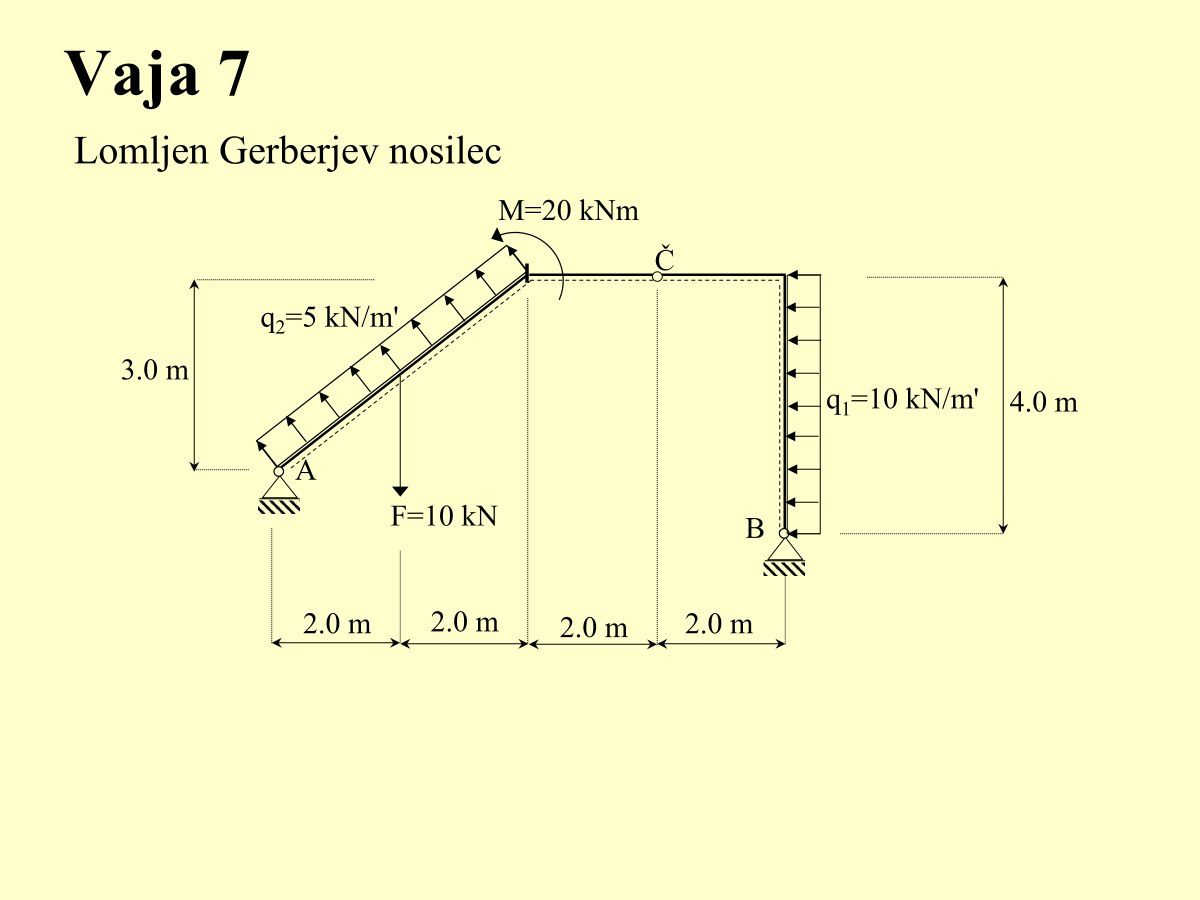

Na sliki je prikazan lomljen Gerberjev nosilec, ki ga v členku $Č$ lahko razcepimo na dve togi telesi. Za levo togo telo nas zanima, kje so upogibni momenti največji in koliko znašajo. Izračun moramo narediti posebej na vsakem delu telesa, kjer se sile spreminjajo. 

Iz ravnotežnih enačb smo izračunali, da je funkcija, ki opisuje upogibni moment med točko $A$ in točko, kjer deluje koncentrirana sila $F$:
$$M(x) = (-X_A\cdot sin(\alpha) + Y_A*cos(\alpha))\cdot x + \frac{5\cdot x^2}{2}$$

kjer je:
- $X_A$ - reakcija v smeri X (horizontalna komponenta) v podpori A
- $Y_A$ - reakcija v smeri Y (vertikalna komponenta) v podpori A
- $\alpha$ - naklon nosilca

Izračunati moramo $x$ in $M(x)$, kjer je $M(X)$ največji.

### Rešitev
Spomnimo, da se ekstrem nahaja v točki, kjer je odvod funkcije enak 0. Zato bomo poiskali odvod $M^\prime(x)$ in točko, kjer je odvod enak 0. 

Ker ne rešujemo celotne naloge, bomo uporabili že izračunane vrednosti reakcij.

In [4]:
alpha = np.arctan(3/4)
X_A = 26.833
Y_A = 6.333

Definirajmo funkcijo $M(x)$, kot je podana zgoraj.

In [11]:
def M(x):
    return (-X_A*np.sin(alpha) + Y_A*np.cos(alpha))*x + 5*x**2/2

Za boljše razumevanje, lahko potek funkcije prikažemo v grafu.

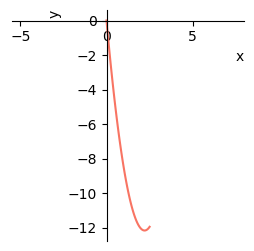

In [68]:
ax = graf(3,3)
x = np.linspace(0, 2.5, 100)  # sila F deluje 2.5 metra desno od podpore A
y = M(x)
ax.plot(x,y);

Iz grafa funkcije vidimo, da ima funkcija ekstrem malo pred koncem intervala.

Izračunajmo odvod funkcije $M^\prime(x)$ in narišimo potek odvoda.

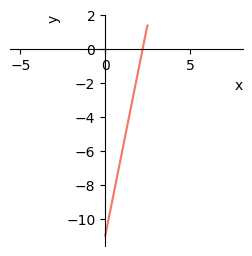

In [69]:
M_prime = np.gradient(M(x), x[1]-x[0])

ax = graf(3,3)
ax.plot(x, M_prime);

Poiskati hočemo tisti $x$, kjer je $M^\prime = 0$ in grafično smo rešitev že našli in se nahaja v bližini vrednosti 2. 

Preverimo še številske vrednosti odvodov: 

In [70]:
M_prime

array([-10.97026869, -10.90713737, -10.78087475, -10.65461212,
       -10.52834949, -10.40208687, -10.27582424, -10.14956162,
       -10.02329899,  -9.89703636,  -9.77077374,  -9.64451111,
        -9.51824848,  -9.39198586,  -9.26572323,  -9.13946061,
        -9.01319798,  -8.88693535,  -8.76067273,  -8.6344101 ,
        -8.50814747,  -8.38188485,  -8.25562222,  -8.1293596 ,
        -8.00309697,  -7.87683434,  -7.75057172,  -7.62430909,
        -7.49804646,  -7.37178384,  -7.24552121,  -7.11925859,
        -6.99299596,  -6.86673333,  -6.74047071,  -6.61420808,
        -6.48794545,  -6.36168283,  -6.2354202 ,  -6.10915758,
        -5.98289495,  -5.85663232,  -5.7303697 ,  -5.60410707,
        -5.47784444,  -5.35158182,  -5.22531919,  -5.09905657,
        -4.97279394,  -4.84653131,  -4.72026869,  -4.59400606,
        -4.46774343,  -4.34148081,  -4.21521818,  -4.08895556,
        -3.96269293,  -3.8364303 ,  -3.71016768,  -3.58390505,
        -3.45764242,  -3.3313798 ,  -3.20511717,  -3.07

Iz seznama števil vidimo, da se negativna števila v eni točki spremenijo v pozitivna. Vendar kako poiskati indeks, kjer se to zgodi?

Funkcija `where()` vrne seznam indeksov tistih elementov, ki ustrezajo določenemu pogoju. Bodite pozorni, da funkcija vrne n-terico seznamov in ne le en seznam indeksov. Zgodilo bi se namreč lahko, da M_prime ni enodimenzonalni seznam in bi takrat funkcija vrnila indekse zbrane po vseh dimenzijah.

In [71]:
pozitivni = np.where(M_prime > 0)
pozitivni

(array([88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]),)

Nas zanima prva vrednost v rezultatu, saj je to mesto, kjer se negativen predznak obrne v pozitivnega.

In [72]:
nicla = pozitivni[0][0]
nicla

88

Sedaj lahko izpišemo pri kateri vrednosti $x$ se zgodi obrat in kolikšna je vrednost momenta.

In [73]:
x[nicla]

2.2222222222222223

In [74]:
y[nicla] 

-12.17298765432098

Zavedati se moramo, da smo izračunali približke, ki so odvisni od gostote izračunanih točk. Če želimo natančnejši rezultat, bomo število točk ustrezno povečali.